In [1]:
import pandas as pd
print("Pandas loaded successfully")

Pandas loaded successfully


In [3]:
trades = pd.read_csv("Data/historical_data.csv")
sentiment = pd.read_excel("Data/fear_greed_index.xlsx")

print(trades.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [4]:
print(trades.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [5]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [7]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['date'] = sentiment['date'].dt.date

In [8]:
print(trades[['Timestamp IST', 'date']].head())
print(sentiment[['date', 'classification']].head())

        Timestamp IST        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02
         date classification
0  2018-02-01           Fear
1  2018-02-02   Extreme Fear
2  2018-02-03           Fear
3  2018-02-04   Extreme Fear
4  2018-02-05   Extreme Fear


In [9]:
print("Trades date range:")
print(trades['date'].min(), "to", trades['date'].max())

print("\nSentiment date range:")
print(sentiment['date'].min(), "to", sentiment['date'].max())

Trades date range:
2023-05-01 to 2025-05-01

Sentiment date range:
2018-02-01 to 2025-05-02


In [10]:
merged = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [11]:
print(merged[['date', 'Closed PnL', 'classification']].head())

         date  Closed PnL classification
0  2024-12-02         0.0  Extreme Greed
1  2024-12-02         0.0  Extreme Greed
2  2024-12-02         0.0  Extreme Greed
3  2024-12-02         0.0  Extreme Greed
4  2024-12-02         0.0  Extreme Greed


In [12]:
print(merged['classification'].isnull().sum())

6


In [13]:
merged = merged.dropna(subset=['classification'])

In [14]:
print(merged['classification'].isnull().sum())

0


In [15]:
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean()

print(pnl_by_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [16]:
merged['is_profit'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['is_profit'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: is_profit, dtype: float64


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

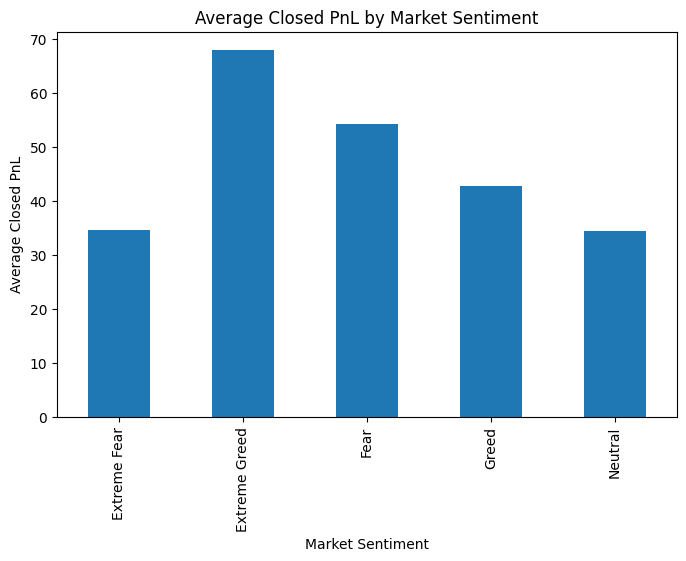

In [19]:
plt.figure(figsize=(8,5))

pnl_by_sentiment.plot(kind='bar')

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

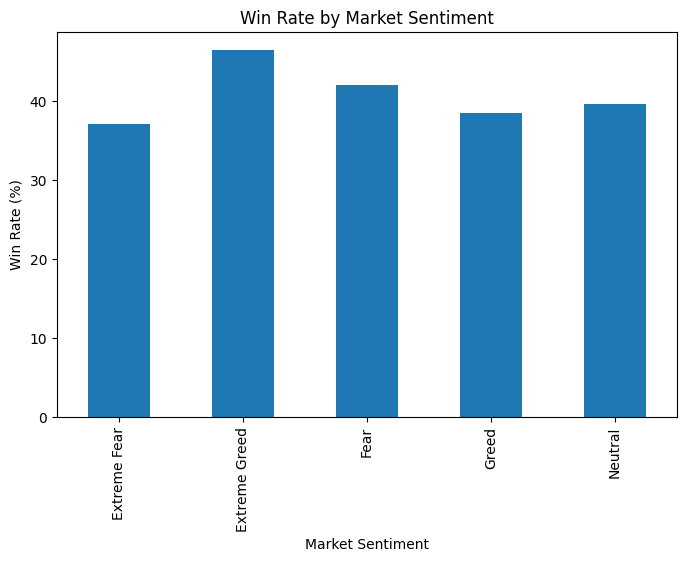

In [20]:
plt.figure(figsize=(8,5))

win_rate.plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.show()

In [21]:
buy_sell_pnl = merged.groupby(
    ['classification', 'Side']
)['Closed PnL'].mean()

print(buy_sell_pnl)

classification  Side
Extreme Fear    BUY      34.114627
                SELL     34.980106
Extreme Greed   BUY      10.498927
                SELL    114.584643
Fear            BUY      63.927104
                SELL     45.049641
Greed           BUY      25.002302
                SELL     59.691091
Neutral         BUY      29.227429
                SELL     39.456408
Name: Closed PnL, dtype: float64


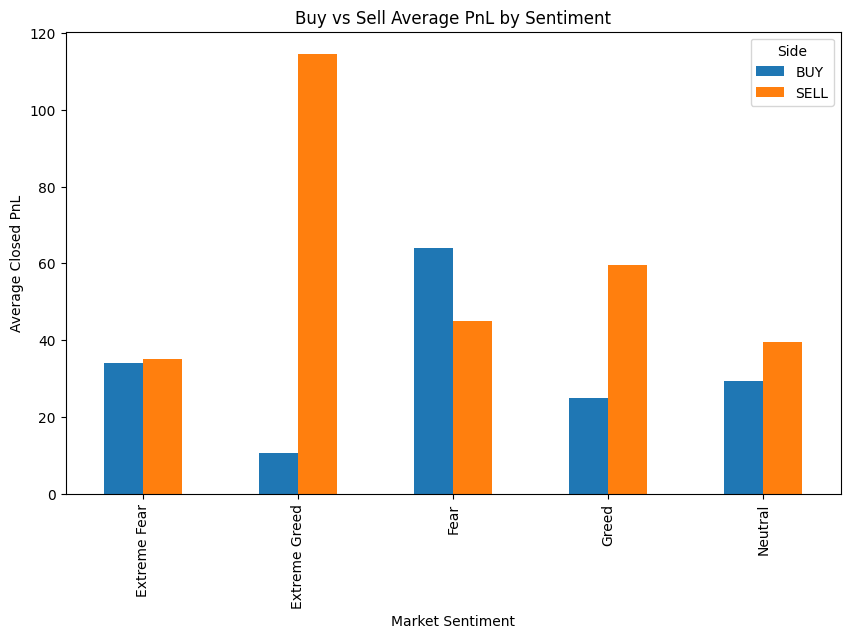

In [22]:
buy_sell_pnl.unstack().plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Buy vs Sell Average PnL by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

In [23]:
size_by_sentiment = merged.groupby(
    'classification'
)['Size USD'].mean()

print(size_by_sentiment)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


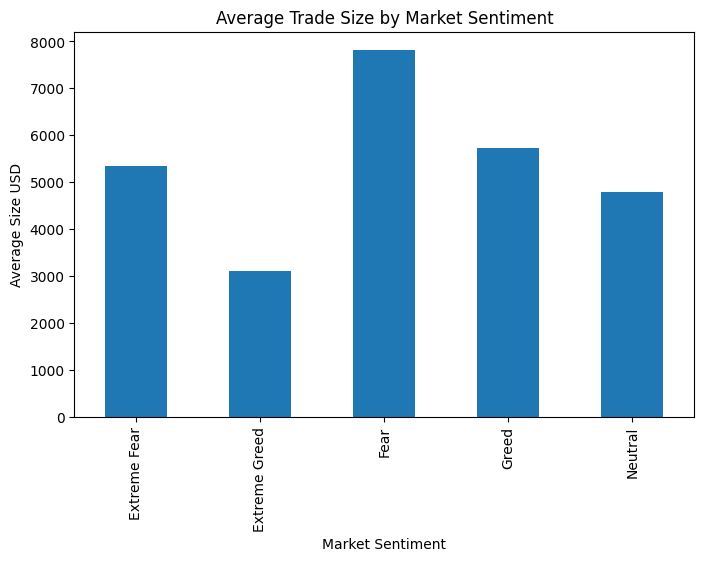

In [24]:
size_by_sentiment.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Size USD")

plt.show()

In [ ]:
Are traders more active in fear or greed?

In [25]:
trade_count = merged['classification'].value_counts()

print(trade_count)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


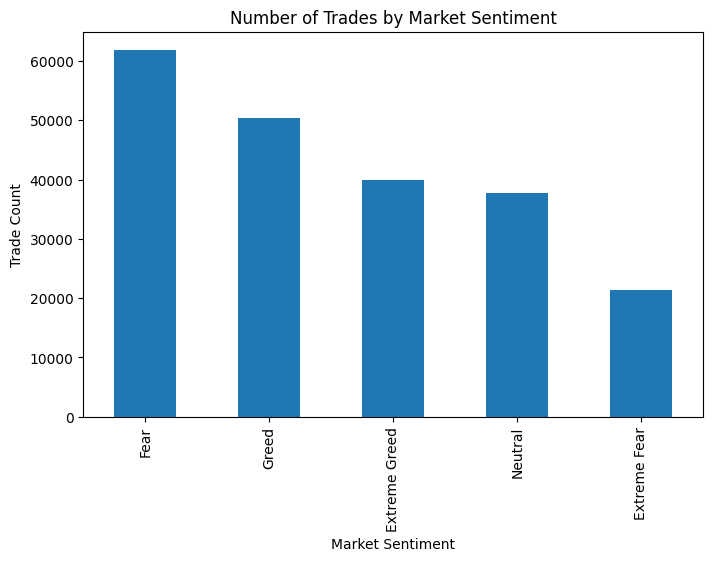

In [26]:
trade_count.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")

plt.show()

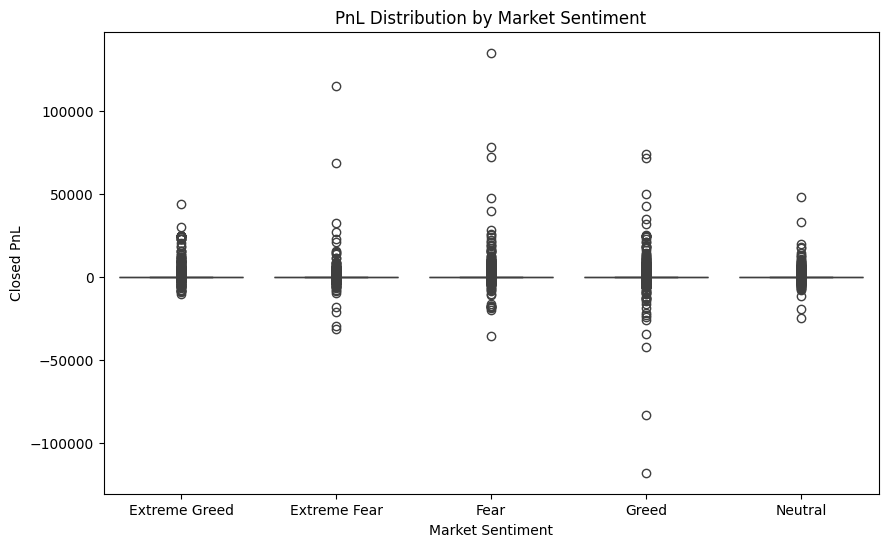

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title("PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()
